<a href="https://colab.research.google.com/github/Radhakrishna200220/E-commerce-website/blob/main/Customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import datetime as dt

In [4]:
df = pd.read_csv('/content/online_mall_datset.csv')

In [5]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I602276,40,Male,70,Stationery,3,2499.05,Cash,10-17-2023,Forum Istanbul
1,I804025,8,Female,66,Healthcare,8,325.62,Debit Card,07-02-2023,Metrocity
2,I016525,6,Female,45,Grocery,2,1817.69,Credit Card,05-30-2023,Emaar Square Mall
3,I808631,16,Female,70,Kitchenware,4,1289.23,Cash,04-29-2022,Cevahir Mall
4,I930086,80,Male,50,Stationery,6,393.55,Credit Card,02-15-2024,Cevahir Mall


In [6]:
df.tail()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
49995,I929219,11,Female,44,Kitchenware,2,462.03,Debit Card,07-09-2023,Cevahir Mall
49996,I288271,75,Male,65,Electronics,6,2754.04,Credit Card,07-02-2023,Emaar Square Mall
49997,I509748,55,Male,65,Healthcare,5,132.26,Credit Card,08-16-2022,Kanyon
49998,I941101,42,Male,74,Shoes,7,859.89,Cash,07-25-2023,Mall of Istanbul
49999,I816211,43,Male,54,Home Appliances,7,922.93,Cash,09-07-2023,Marmara Forum


In [7]:
df.shape

(50000, 10)

In [8]:
df.isna().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      50000 non-null  object 
 1   customer_id     50000 non-null  int64  
 2   gender          50000 non-null  object 
 3   age             50000 non-null  int64  
 4   category        50000 non-null  object 
 5   quantity        50000 non-null  int64  
 6   price           50000 non-null  float64
 7   payment_method  50000 non-null  object 
 8   invoice_date    50000 non-null  object 
 9   shopping_mall   50000 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 3.8+ MB


In [10]:
df.describe()

,customer_id,age,quantity,price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,49.962320,48.926000,5.497200,1515.014933
std,29.189427,18.167838,2.875719,866.395988
min,0.000000,18.000000,1.000000,10.070000
25%,25.000000,33.000000,3.000000,765.360000
50%,50.000000,49.000000,5.000000,1522.530000
75%,75.000000,65.000000,8.000000,2270.375000
max,100.000000,80.000000,10.000000,2999.970000


In [11]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'],infer_datetime_format=True,format='mixed',utc=True, errors='ignore')

<ipython-input-11-20bb67d1c44c>:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['invoice_date'] = pd.to_datetime(df['invoice_date'],infer_datetime_format=True,format='mixed',utc=True, errors='ignore')
<ipython-input-11-20bb67d1c44c>:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df['invoice_date'] = pd.to_datetime(df['invoice_date'],infer_datetime_format=True,format='mixed',utc=True, errors='ignore')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   invoice_no      50000 non-null  object             
 1   customer_id     50000 non-null  int64              
 2   gender          50000 non-null  object             
 3   age             50000 non-null  int64              
 4   category        50000 non-null  object             
 5   quantity        50000 non-null  int64              
 6   price           50000 non-null  float64            
 7   payment_method  50000 non-null  object             
 8   invoice_date    50000 non-null  datetime64[ns, UTC]
 9   shopping_mall   50000 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(5)
memory usage: 3.8+ MB


In [13]:
df_recency = df.groupby(by='customer_id',
                        as_index=False)['invoice_date'].max()
df_recency.columns = ['customer_id', 'invoice_date']
recent_date = df_recency['invoice_date'].max()
df_recency['Recency'] = df_recency['invoice_date'].apply(
    lambda x: (recent_date - x).days)
df_recency.head()

,customer_id,invoice_date,Recency
0,0,2024-04-18 00:00:00+00:00,5
1,1,2024-04-23 00:00:00+00:00,0
2,2,2024-04-23 00:00:00+00:00,0
3,3,2024-04-22 00:00:00+00:00,1
4,4,2024-04-23 00:00:00+00:00,0


In [14]:
frequency_df = df.drop_duplicates().groupby(
	by=['customer_id'], as_index=False)['invoice_date'].count()
frequency_df.columns = ['customer_id', 'Frequency']
frequency_df.head()

,customer_id,Frequency
0,0,526
1,1,477
2,2,521
3,3,475
4,4,556


In [15]:
monetary_df = df.groupby('customer_id')['price'].sum().reset_index()
monetary_scores = pd.qcut(monetary_df['price'], q=4, labels=range(1, 5))
monetary_df.columns = ['customer_id', 'Monetary']
monetary_df.head()

,customer_id,Monetary
0,0,784112.80
1,1,712341.76
2,2,793373.30
3,3,748069.23
4,4,864811.74


In [16]:
rf_df = df_recency.merge(frequency_df, on='customer_id')
rfm_df = rf_df.merge(monetary_df, on='customer_id').drop(
	columns='invoice_date')
rfm_df.head()

,customer_id,Recency,Frequency,Monetary
0,0,5,526,784112.80
1,1,0,477,712341.76
2,2,0,521,793373.30
3,3,1,475,748069.23
4,4,0,556,864811.74


In [17]:
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)

# normalizing the rank of the customers
rfm_df['R_rank_norm'] = (rfm_df['R_rank']/rfm_df['R_rank'].max())*100
rfm_df['F_rank_norm'] = (rfm_df['F_rank']/rfm_df['F_rank'].max())*100
rfm_df['M_rank_norm'] = (rfm_df['F_rank']/rfm_df['M_rank'].max())*100

rfm_df.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)

rfm_df.head()

,customer_id,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,0,5,526,784112.80,4.848485,93.034826,92.574257
1,1,0,477,712341.76,100.000000,28.358209,28.217822
2,2,0,521,793373.30,100.000000,84.577114,84.158416
3,3,1,475,748069.23,55.151515,21.890547,21.782178
4,4,0,556,864811.74,100.000000,100.000000,99.504950


In [18]:
rfm_df['RFM_Score'] = 0.15*rfm_df['R_rank_norm']+0.28 * \
	rfm_df['F_rank_norm']+0.57*rfm_df['M_rank_norm']
rfm_df['RFM_Score'] *= 0.05
rfm_df = rfm_df.round(9)
rfm_df[['customer_id', 'RFM_Score']].head(7)

,customer_id,RFM_Score
0,0,3.977218
1,1,1.951223
2,2,4.332594
3,3,1.340896
4,4,4.985891
5,5,2.921452
6,6,1.467341


In [19]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
batch_size = 170

In [20]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)

In [21]:
kmeans = MiniBatchKMeans(n_clusters = 3,random_state=42, batch_size=170)
kmeans.fit(rfm_scaled)
cluster_labels = kmeans.predict(rfm_scaled)

In [22]:
kmeans.fit(rfm_scaled)

MiniBatchKMeans(batch_size=170, n_clusters=3, random_state=42)

In [23]:
rfm_df['Cluster'] = cluster_labels

In [24]:
print(rfm_df['Cluster'].value_counts())

Cluster
1    53
0    27
2    21
Name: count, dtype: int64


In [25]:
import matplotlib.pyplot as plt
%matplotlib inline

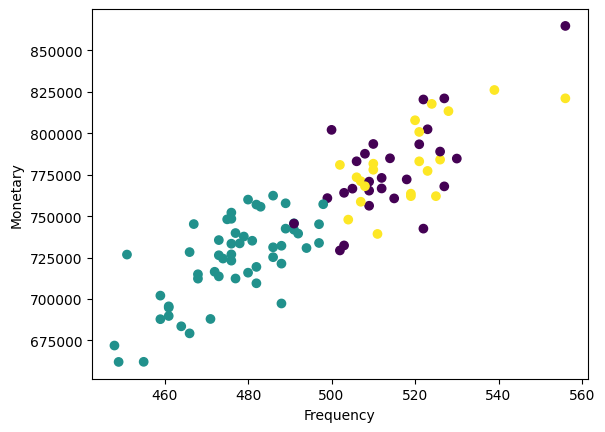

In [26]:
plt.scatter(rfm_df['Frequency'], rfm_df['Monetary'], c=rfm_df['Cluster'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

In [27]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [28]:
silhouette = silhouette_score(rfm_scaled, cluster_labels)
print(f"Silhouette score: {silhouette}")

Silhouette score: 0.28050310232494496


In [29]:
davies_bouldin = davies_bouldin_score(rfm_scaled, cluster_labels)
print(f"Davies-Bouldin index: {davies_bouldin}")

Davies-Bouldin index: 1.2886309890357268


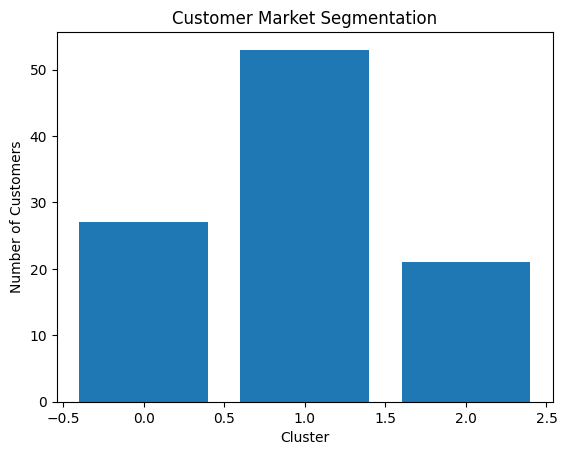

In [30]:
cluster_counts = rfm_df['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Market Segmentation')
plt.show()